In [1]:
import pandas as pd

df = pd.read_csv("../data/processed_telco.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,RevenueScore,AvgMonthlySpend,TenureGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.85,14.925000,New
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,1936.30,53.985714,Established
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,107.70,36.050000,New
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,1903.50,40.016304,Established
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,141.40,50.550000,New


In [2]:
segmentation_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "RevenueScore"
]

In [3]:
X_seg = df[
    segmentation_features
].copy()

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_seg
)

In [5]:
from sklearn.cluster import KMeans

In [6]:
inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertia.append(
        kmeans.inertia_
    )

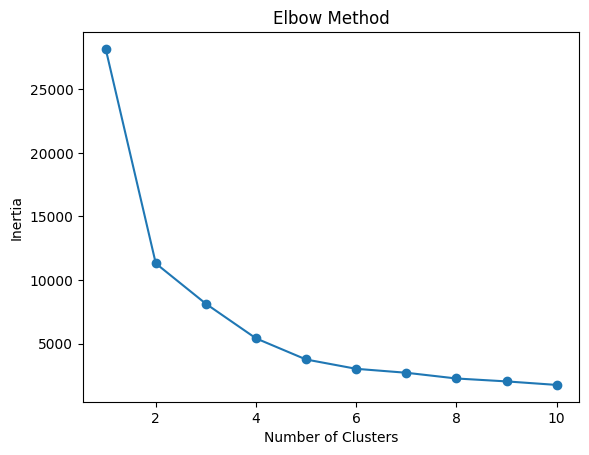

In [7]:
import matplotlib.pyplot as plt

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(
    X_scaled
)

In [9]:
df["Cluster"].value_counts()

Cluster
3    2241
1    1870
2    1753
0    1179
Name: count, dtype: int64

In [10]:
cluster_summary = df.groupby("Cluster")[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "RevenueScore"
]].mean()

cluster_summary

,tenure,MonthlyCharges,TotalCharges,RevenueScore
Cluster,,,,
0,53.564885,36.981552,1920.736768,1919.851654
1,59.810160,93.629465,5588.788610,5586.173743
2,10.600685,31.799002,312.506874,306.381004
3,15.354306,81.073003,1253.071408,1253.170705


In [11]:
segment_mapping = {
    0: "Loyal Customers",
    1: "Premium Customers",
    2: "Growing Customers",
    3: "At-Risk High-Value Customers"
}

df["CustomerSegment"] = df["Cluster"].map(
    segment_mapping
)

In [12]:
df["CustomerSegment"].value_counts()

CustomerSegment
At-Risk High-Value Customers    2241
Premium Customers               1870
Growing Customers               1753
Loyal Customers                 1179
Name: count, dtype: int64

In [13]:
df.to_csv(
    "../data/customer_intelligence_dataset.csv",
    index=False
)